# Project - 3 Correlation heatmap & pairwise relationships
 Author: Banele Seko 



# Step 1 Installing Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2 Reading the Dataset

In [4]:
df = pd.read_csv("sales.csv")
df.head()

,SalesOrderNumber,SalesOrderLineNumber,OrderDate,CustomerName,EmailAddress,Item,Quantity,UnitPrice,TaxAmount
0,SO43701,1,2019-07-01,Christy Zhu,christy12@adventure-works.com,"Mountain-100 Silver, 44",1,3399.9900,271.9992
1,SO43704,1,2019-07-01,Julio Ruiz,julio1@adventure-works.com,"Mountain-100 Black, 48",1,3374.9900,269.9992
2,SO43705,1,2019-07-01,Curtis Lu,curtis9@adventure-works.com,"Mountain-100 Silver, 38",1,3399.9900,271.9992
3,SO43700,1,2019-07-01,Ruben Prasad,ruben10@adventure-works.com,"Road-650 Black, 62",1,699.0982,55.9279
4,SO43703,1,2019-07-01,Albert Alvarez,albert7@adventure-works.com,"Road-150 Red, 62",1,3578.2700,286.2616


# Step 3 Dataset Information & Statistics

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32718 entries, 0 to 32717
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SalesOrderNumber      32718 non-null  str    
 1   SalesOrderLineNumber  32718 non-null  int64  
 2   OrderDate             32718 non-null  str    
 3   CustomerName          32718 non-null  str    
 4   EmailAddress          32718 non-null  str    
 5   Item                  32718 non-null  str    
 6   Quantity              32718 non-null  int64  
 7   UnitPrice             32718 non-null  float64
 8   TaxAmount             32718 non-null  float64
dtypes: float64(2), int64(2), str(5)
memory usage: 2.2 MB


In [6]:
df.describe()

,SalesOrderLineNumber,Quantity,UnitPrice,TaxAmount
count,32718.000000,32718.0,32718.000000,32718.000000
mean,1.813589,1.0,639.648586,51.171888
std,1.005108,0.0,1072.038921,85.763115
min,1.000000,1.0,2.290000,0.183200
25%,1.000000,1.0,8.990000,0.719200
50%,1.000000,1.0,34.990000,2.799200
75%,2.000000,1.0,782.990000,62.639200
max,8.000000,1.0,3578.270000,286.261600


# Step 4 Exploratory Data analysis

In [7]:
import pandas as pd

#Load sales data
df=pd.read_csv("sales.csv")

#Convert OrderDate to datetime
df["OrderDate"] =pd.to_datetime(df["OrderDate"])

#Display basic information
print(df.head())
print(df.info())

  SalesOrderNumber  SalesOrderLineNumber  OrderDate    CustomerName  \
0          SO43701                     1 2019-07-01     Christy Zhu   
1          SO43704                     1 2019-07-01      Julio Ruiz   
2          SO43705                     1 2019-07-01       Curtis Lu   
3          SO43700                     1 2019-07-01    Ruben Prasad   
4          SO43703                     1 2019-07-01  Albert Alvarez   

                    EmailAddress                     Item  Quantity  \
0  christy12@adventure-works.com  Mountain-100 Silver, 44         1   
1     julio1@adventure-works.com   Mountain-100 Black, 48         1   
2    curtis9@adventure-works.com  Mountain-100 Silver, 38         1   
3    ruben10@adventure-works.com       Road-650 Black, 62         1   
4    albert7@adventure-works.com         Road-150 Red, 62         1   

   UnitPrice  TaxAmount  
0  3399.9900   271.9992  
1  3374.9900   269.9992  
2  3399.9900   271.9992  
3   699.0982    55.9279  
4  3578.2700   2

# Step 5 - Check the numerical columns

In [8]:
numerical_df = df.select_dtypes(include="number")
numerical_df.columns

Index(['SalesOrderLineNumber', 'Quantity', 'UnitPrice', 'TaxAmount'], dtype='str')

In [9]:
numerical_df.nunique()

SalesOrderLineNumber     8
Quantity                 1
UnitPrice               42
TaxAmount               42
dtype: int64

# Step 6 - Create an order-level dataset

In [10]:
order_df = df.groupby("SalesOrderNumber").agg(
    OrderLineCount=("SalesOrderLineNumber", "count"),
    TotalSales=("UnitPrice", "sum"),
    AvgUnitPrice=("UnitPrice", "mean"),
    UniqueItems=("Item", "nunique")
).reset_index()

order_df.head()
                                             

,SalesOrderNumber,OrderLineCount,TotalSales,AvgUnitPrice,UniqueItems
0,SO43697,1,3578.2700,3578.2700,1
1,SO43698,1,3399.9900,3399.9900,1
2,SO43699,1,3399.9900,3399.9900,1
3,SO43700,1,699.0982,699.0982,1
4,SO43701,1,3399.9900,3399.9900,1


# Step 7 Calculate Correlations

In [11]:
correlation_df = order_df[
    ["OrderLineCount", "TotalSales", "AvgUnitPrice"]
]

correlation_matrix = correlation_df.corr(method="pearson")
1
correlation_matrix

,OrderLineCount,TotalSales,AvgUnitPrice
OrderLineCount,1.000000,-0.260540,-0.525988
TotalSales,-0.260540,1.000000,0.905347
AvgUnitPrice,-0.525988,0.905347,1.000000


# Step 8 HeatMap

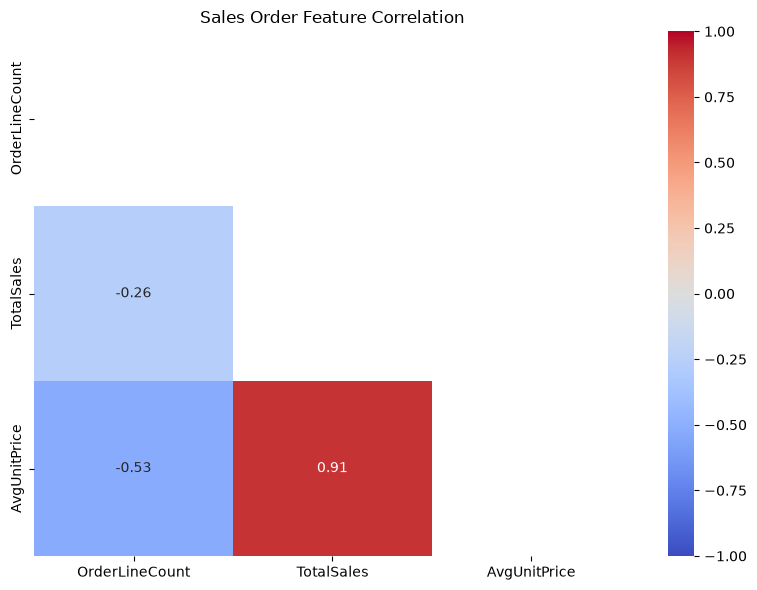

In [12]:
import numpy as np
import os

os.makedirs("Plots", exist_ok=True)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    
    annot=True,
    fmt=".2f",
    
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Sales Order Feature Correlation")
plt.tight_layout()

plt.savefig("Plots/correlation_heatmap.png", dpi=300)

plt.show()

# Step 9 PairWise Relationship

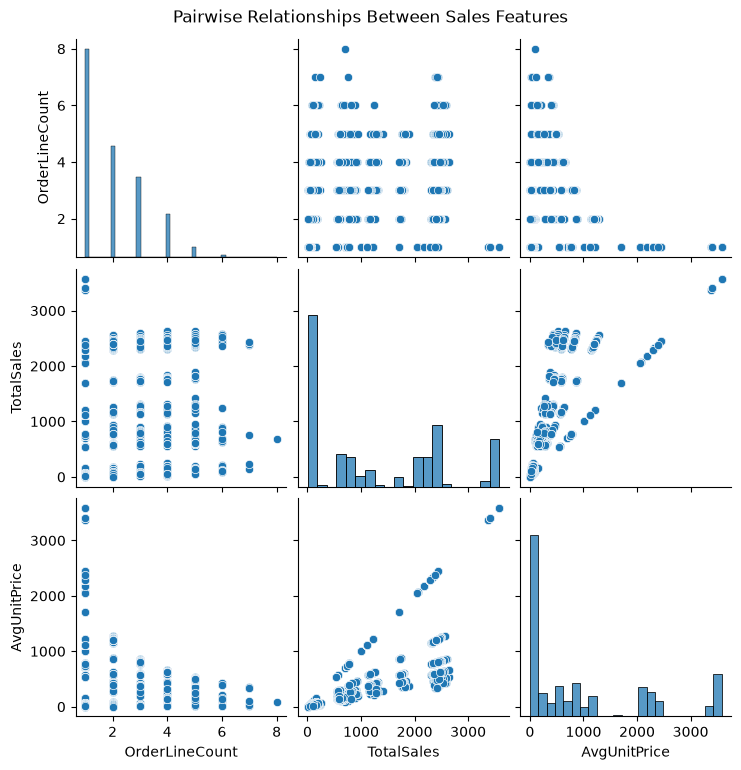

In [13]:
pair_plot = sns.pairplot(
    correlation_df
)

pair_plot.fig.suptitle(
    "Pairwise Relationships Between Sales Features",
    y=1.02
)

pair_plot.fig.savefig(
    "Plots/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 10 Identify Strongest Relationships

In [14]:
corr_pairs =(
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
.stack()
.sort_values()
)

corr_pairs

OrderLineCount  AvgUnitPrice     -0.525988
                TotalSales       -0.260540
TotalSales      AvgUnitPrice      0.905347
OrderLineCount  OrderLineCount         NaN
TotalSales      OrderLineCount         NaN
                TotalSales             NaN
AvgUnitPrice    OrderLineCount         NaN
                TotalSales             NaN
                AvgUnitPrice           NaN
dtype: float64

# Step 11 Scatter Plot

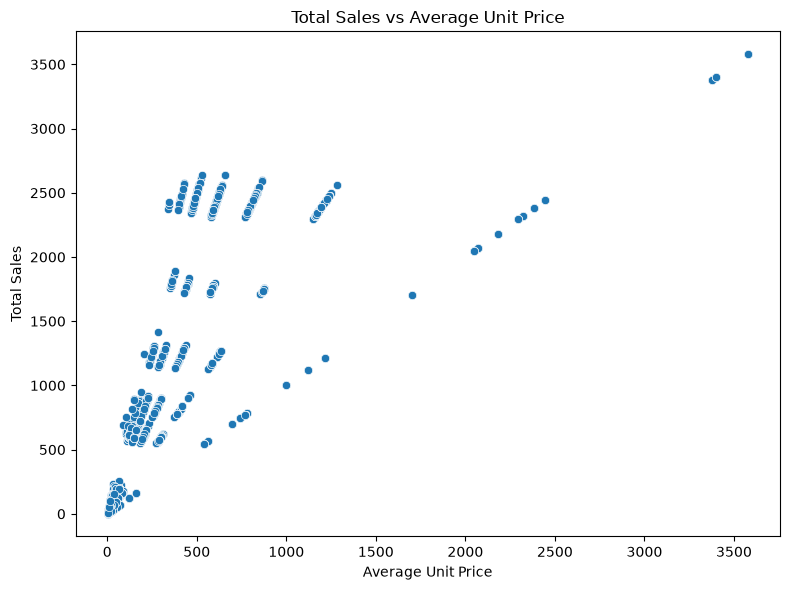

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=order_df,
    x="AvgUnitPrice",
    y="TotalSales"
)

plt.title("Total Sales vs Average Unit Price")
plt.xlabel("Average Unit Price")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "Plots/scatter_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()